In [1]:
"""
Manifold of admissible logistic decoders via Fisher geometry + NMF

- Fits logistic regression on true + permuted labels
- Computes diagonal Fisher information fingerprints
- Uses NMF to discover canonical decoder geometries

Safe for ~40k neurons, ~100–300 fits
"""

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import NMF

# ============================================================
# PATHS
# ============================================================
VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================
vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

print("Images:", vit.shape[0])
print("Neurons:", R.shape[1])

# ============================================================
# ANIMATE / INANIMATE LABEL
# ============================================================
top1 = np.argmax(vit, axis=1)
y_true = (top1 <= 397).astype(int)
print("Animate fraction:", y_true.mean())

# ============================================================
# LOGISTIC REGRESSION + FISHER (DIAGONAL)
# ============================================================
def fisher_diag_logreg(X, y, C=1.0):
    """
    Fit logistic regression and return diagonal Fisher information
    """
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xz = scaler.fit_transform(X)

    clf = LogisticRegression(
        penalty='l2',
        C=C,
        solver='lbfgs',
        max_iter=500
    )
    clf.fit(Xz, y)

    p = clf.predict_proba(Xz)[:, 1]
    w = p * (1 - p)                      # uncertainty weights

    fisher_diag = np.mean(w[:, None] * (Xz ** 2), axis=0)
    return fisher_diag

# ============================================================
# COLLECT FISHER FINGERPRINTS
# ============================================================
n_fits = 200          # adjust (100–500 is reasonable)
F = []

for k in range(n_fits):
    if k == 0:
        yk = y_true.copy()
        label_type = "TRUE"
    else:
        yk = np.random.permutation(y_true)
        label_type = "PERM"

    fisher = fisher_diag_logreg(R, yk)
    fisher /= fisher.sum()               # normalize scale
    F.append(fisher)

    if k % 20 == 0:
        print(f"Fit {k:3d} ({label_type})")

F = np.stack(F)                          # (n_fits, n_neurons)
print("Fisher matrix shape:", F.shape)

# ============================================================
# NMF: MANIFOLD OF ADMISSIBLE SOLUTIONS
# ============================================================
n_components = 5

nmf = NMF(
    n_components=n_components,
    init='nndsvda',
    max_iter=2000,
    random_state=0
)

W = nmf.fit_transform(F)                 # (n_fits, n_components)
H = nmf.components_                      # (n_components, n_neurons)

print("NMF done.")
print("W shape:", W.shape)
print("H shape:", H.shape)

# ============================================================
# BASIC INTERPRETATION
# ============================================================
print("\nComponent loadings for TRUE labels:")
print(W[0])

print("\nMean component loadings for PERMUTED labels:")
print(W[1:].mean(axis=0))

print("\nStd of component loadings for PERMUTED labels:")
print(W[1:].std(axis=0))

# ============================================================
# OPTIONAL: SAVE RESULTS
# ============================================================
np.save("fisher_nmf_W.npy", W)
np.save("fisher_nmf_H.npy", H)


Images: 118
Neurons: 39209
Animate fraction: 0.5338983050847458
Fit   0 (TRUE)
Fit  20 (PERM)
Fit  40 (PERM)
Fit  60 (PERM)
Fit  80 (PERM)
Fit 100 (PERM)
Fit 120 (PERM)
Fit 140 (PERM)
Fit 160 (PERM)
Fit 180 (PERM)
Fisher matrix shape: (200, 39209)


/home/maria/global_venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(


NMF done.
W shape: (200, 5)
H shape: (5, 39209)

Component loadings for TRUE labels:
[0.01521543 0.00098546 0.01372111 0.00280605 0.00434938]

Mean component loadings for PERMUTED labels:
[0.01202128 0.00435924 0.01010596 0.00443035 0.0086018 ]

Std of component loadings for PERMUTED labels:
[0.00284984 0.00338992 0.00435414 0.0024407  0.00426403]


Fits: 200 Components: 5


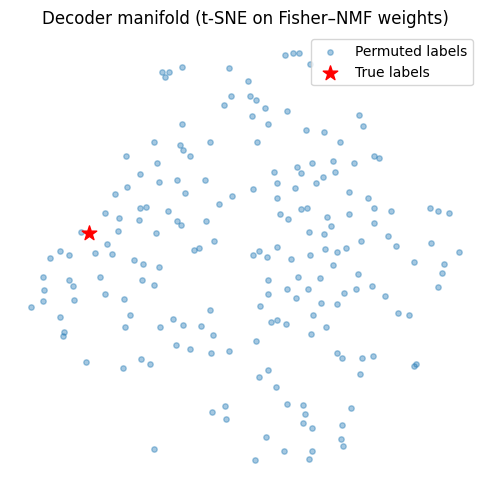

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ============================================================
# LOAD
# ============================================================
W = np.load("fisher_nmf_W.npy")   # (n_fits, n_components)

n_fits, n_components = W.shape
print("Fits:", n_fits, "Components:", n_components)

# First row = TRUE labels by construction
is_true = np.zeros(n_fits, dtype=bool)
is_true[0] = True

# ============================================================
# t-SNE
# ============================================================
Wz = W / (W.sum(axis=1, keepdims=True) + 1e-12)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=0
)

Z = tsne.fit_transform(Wz)

# ============================================================
# PLOT
# ============================================================
plt.figure(figsize=(5, 5))
plt.scatter(Z[~is_true, 0], Z[~is_true, 1],
            s=15, alpha=0.4, label="Permuted labels")
plt.scatter(Z[is_true, 0], Z[is_true, 1],
            s=120, c='red', marker='*', label="True labels")

plt.title("Decoder manifold (t-SNE on Fisher–NMF weights)")
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()


Fits: 200 Components: 5


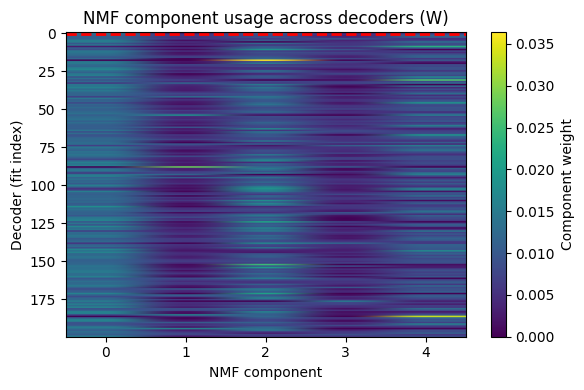

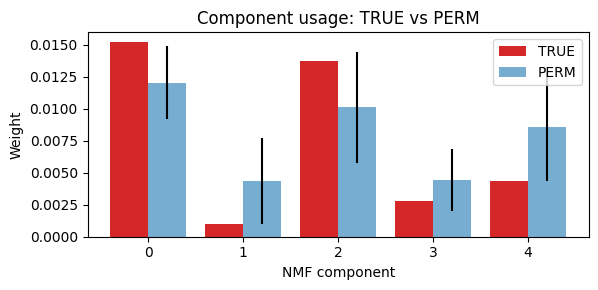

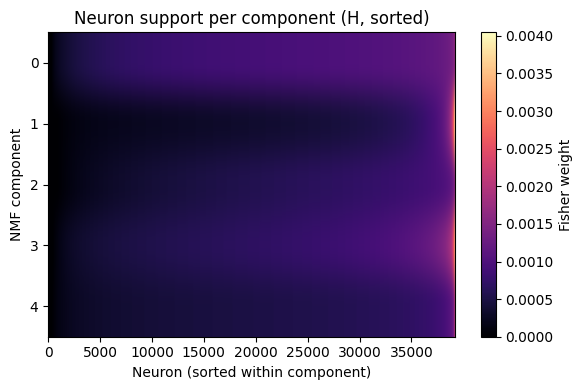

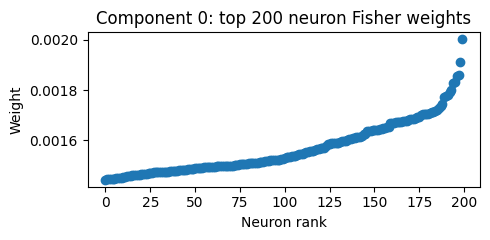

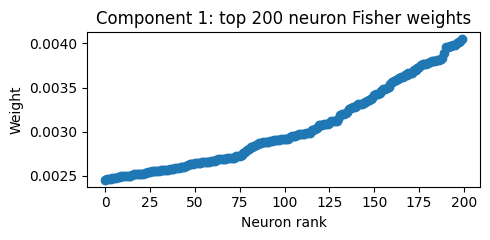

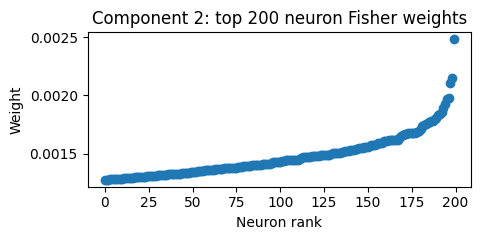

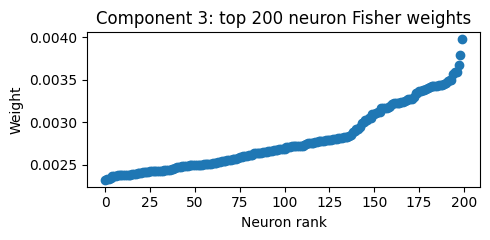

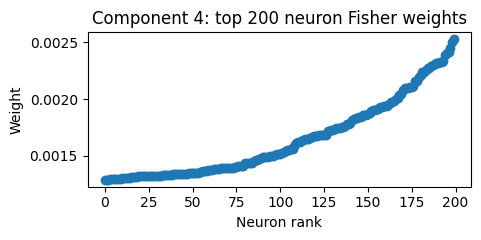

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD NMF RESULTS
# ============================================================
W = np.load("fisher_nmf_W.npy")   # (n_fits, n_components)
H = np.load("fisher_nmf_H.npy")   # (n_components, n_neurons)

n_fits, n_components = W.shape
print("Fits:", n_fits, "Components:", n_components)

# By construction: row 0 = TRUE labels
is_true = np.zeros(n_fits, dtype=bool)
is_true[0] = True

# ============================================================
# 1️⃣ COMPONENT USAGE ACROSS DECODERS (W)
# ============================================================
plt.figure(figsize=(6, 4))
plt.imshow(W, aspect='auto', cmap='viridis')
plt.colorbar(label="Component weight")
plt.axhline(0.5, color='red', linestyle='--', linewidth=2)
plt.xlabel("NMF component")
plt.ylabel("Decoder (fit index)")
plt.title("NMF component usage across decoders (W)")
plt.tight_layout()
plt.show()

# Interpretation:
# - Row 0 (above red line) = TRUE labels
# - Look for components where row 0 is atypical

# ============================================================
# 2️⃣ AGGREGATED COMPONENT USAGE: TRUE vs PERM
# ============================================================
plt.figure(figsize=(6, 3))

plt.bar(
    np.arange(n_components) - 0.2,
    W[0],
    width=0.4,
    label="TRUE",
    color="tab:red"
)

plt.bar(
    np.arange(n_components) + 0.2,
    W[1:].mean(axis=0),
    yerr=W[1:].std(axis=0),
    width=0.4,
    label="PERM",
    color="tab:blue",
    alpha=0.6
)

plt.xlabel("NMF component")
plt.ylabel("Weight")
plt.title("Component usage: TRUE vs PERM")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 3️⃣ NEURON SUPPORT PER COMPONENT (H)
# ============================================================
# H is (components × neurons) — too wide to show directly.
# We sort neurons within each component to reveal structure.

H_sorted = np.sort(H, axis=1)

plt.figure(figsize=(6, 4))
plt.imshow(H_sorted, aspect='auto', cmap='magma')
plt.colorbar(label="Fisher weight")
plt.xlabel("Neuron (sorted within component)")
plt.ylabel("NMF component")
plt.title("Neuron support per component (H, sorted)")
plt.tight_layout()
plt.show()

# Interpretation:
# - Flat rows → generic population support
# - Heavy tails → specialized neuron subsets

# ============================================================
# 4️⃣ TOP NEURONS PER COMPONENT (PROFILE VIEW)
# ============================================================
top_k = 200   # show strongest contributors

for k in range(n_components):
    weights = H[k]
    idx = np.argsort(weights)[-top_k:]

    plt.figure(figsize=(5, 2.5))
    plt.plot(weights[idx], marker='o', linestyle='None')
    plt.title(f"Component {k}: top {top_k} neuron Fisher weights")
    plt.xlabel("Neuron rank")
    plt.ylabel("Weight")
    plt.tight_layout()
    plt.show()
